In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/kaggle/input/tatnic/titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df.drop('Cabin', axis=1, inplace=True)

In [6]:
df[df['Age'].isna()].head(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,Q
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,C
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,Q
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,C
42,43,0,3,"Kraeff, Mr. Theodor",male,NaN,0,0,349253,7.8958,C


In [7]:
age_means = df.groupby(['Pclass', 'Sex'])['Age'].mean()
age_means

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64

In [8]:
def fill_age(age):
    if pd.isnull(age['Age']):
        return age_means.loc[age['Pclass'], age['Sex']]
    else:
        return age['Age']

df['Age'] = df.apply(fill_age, axis=1)

In [9]:
df['Embarked'].mode()[0]

'S'

In [10]:
df['Embarked'] = df['Embarked'].fillna('S')

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.318643,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.281103,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.750000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.507589,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


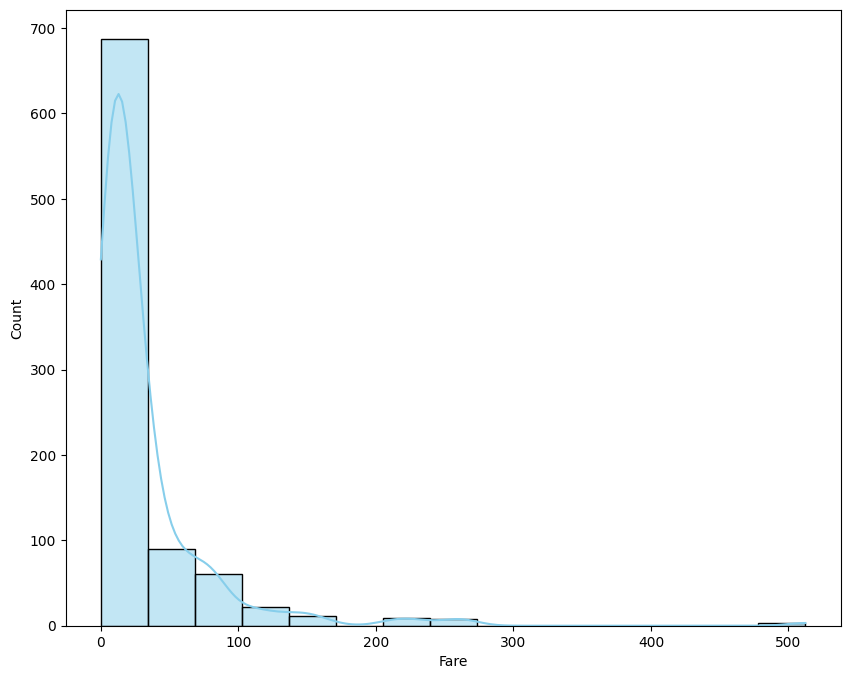

In [13]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Fare' , kde=True , color='skyblue' , edgecolor='black' , bins=15)
plt.show()

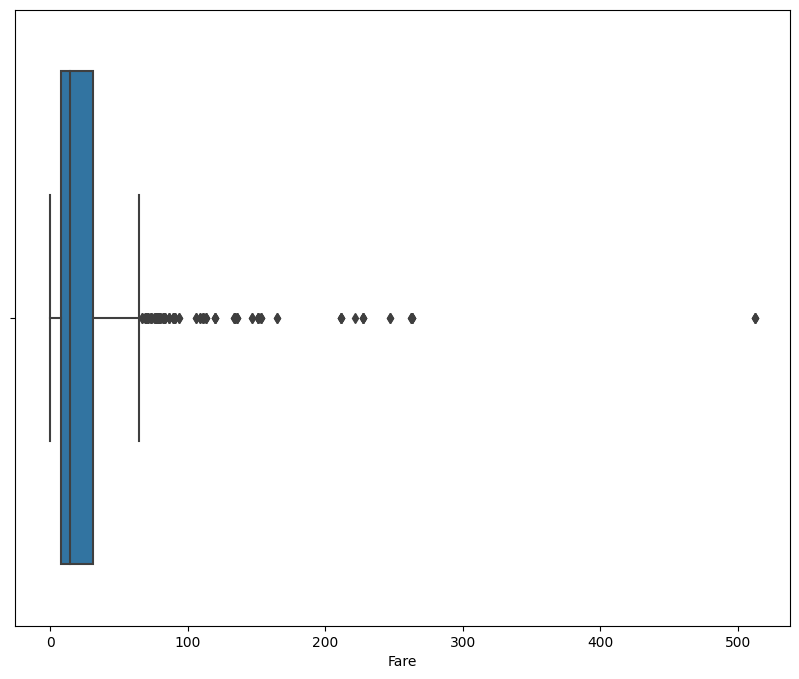

In [14]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Fare')
plt.show()

In [15]:
df['Fare'].agg(['max' , 'mean' , 'min'])

max     512.329200
mean     32.204208
min       0.000000
Name: Fare, dtype: float64

In [16]:
df[df['Fare'] > 450 ] 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C


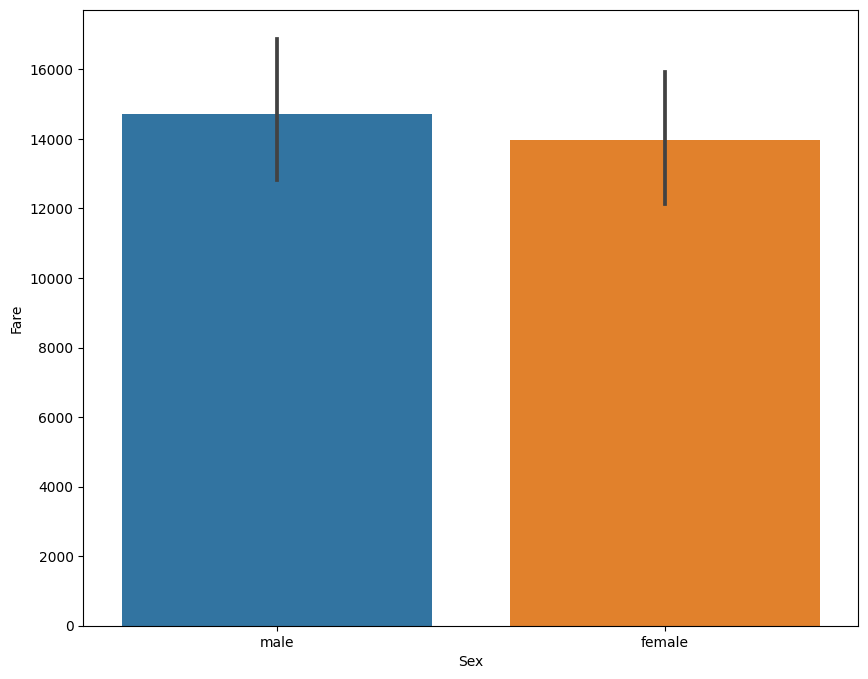

In [17]:
plt.figure(figsize=(10,8))
sns.barplot(data=df , x='Sex' , y='Fare' , estimator=sum)
plt.show()

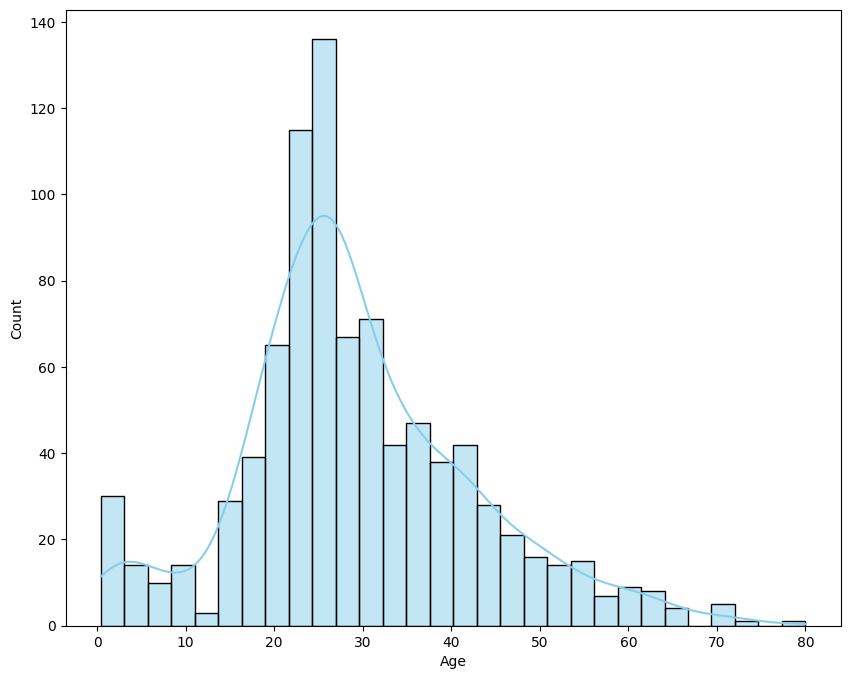

In [18]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Age', bins=30, kde=True, color="skyblue" , edgecolor='black')
plt.show()

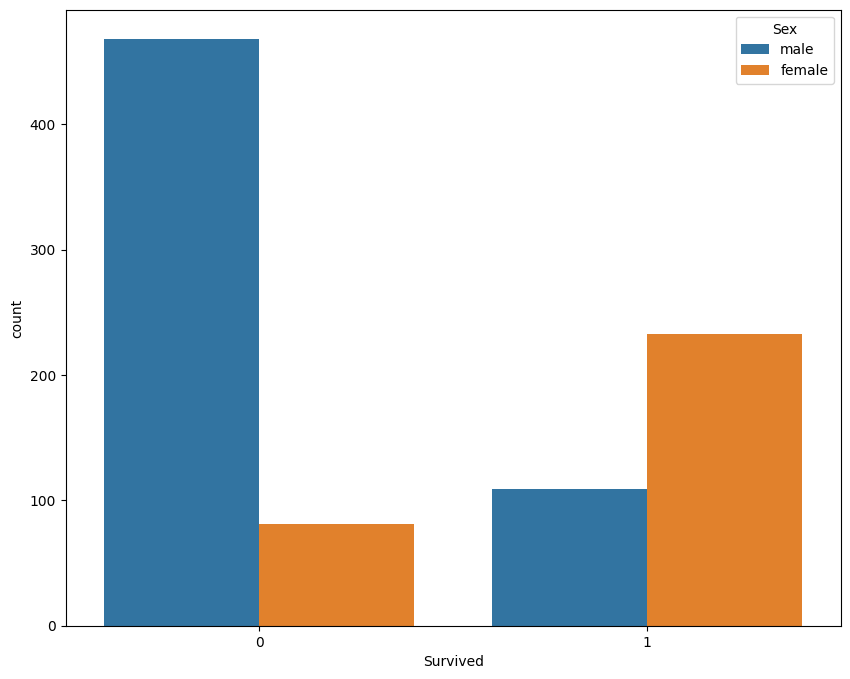

In [19]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x="Survived", hue='Sex')
plt.show()

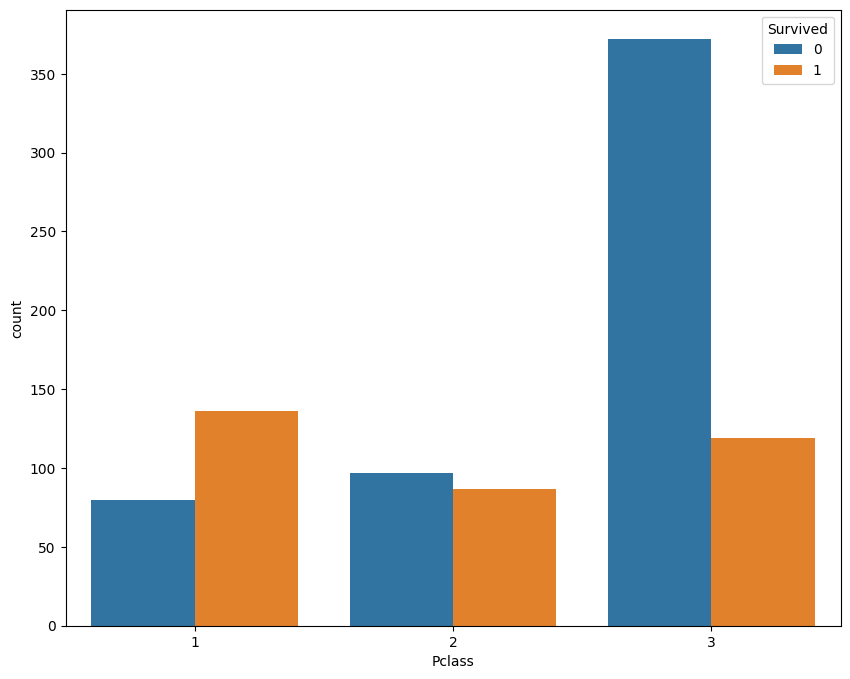

In [20]:
plt.figure(figsize=(10,8))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.show()

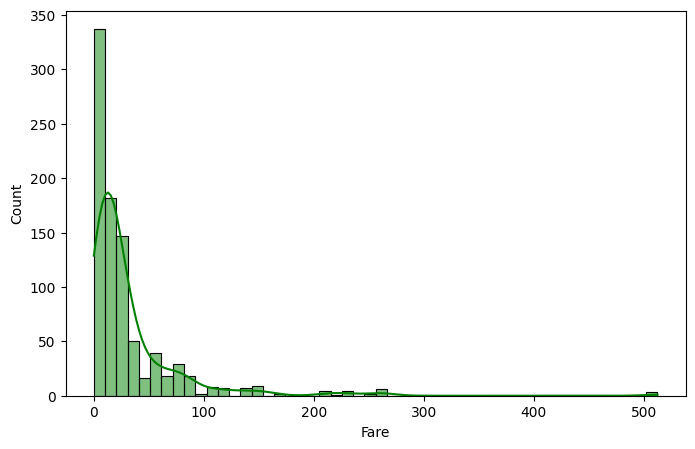

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(data=df , x='Fare' , bins=50, color="green", kde=True , edgecolor='black')
plt.show()

In [22]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.00,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.75,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00,0,0,111369,30.0000,C


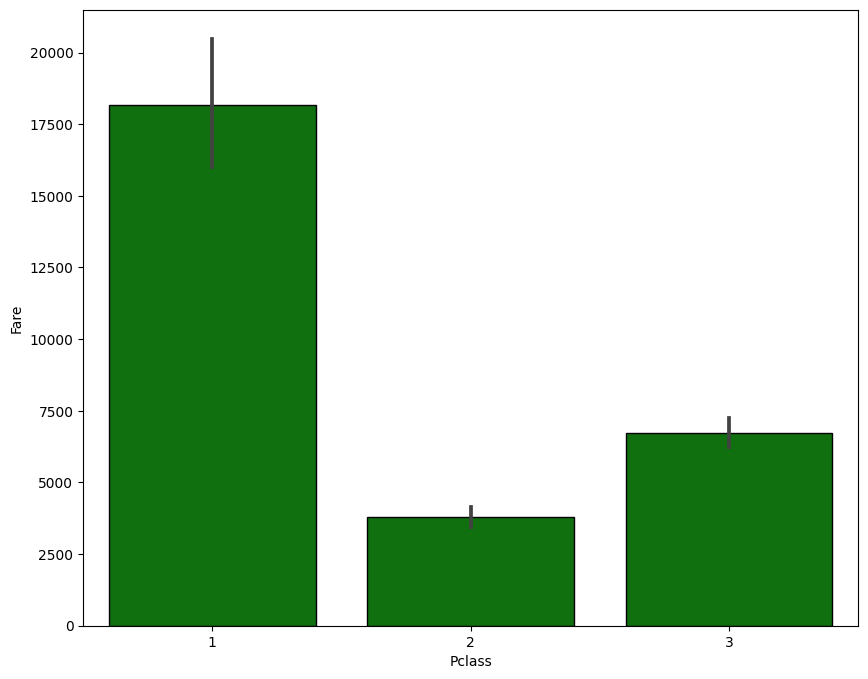

In [23]:
plt.figure(figsize=(10,8))
sns.barplot(data=df, x="Pclass" , y='Fare' , edgecolor='black' , color='green' , estimator=sum)
plt.show()

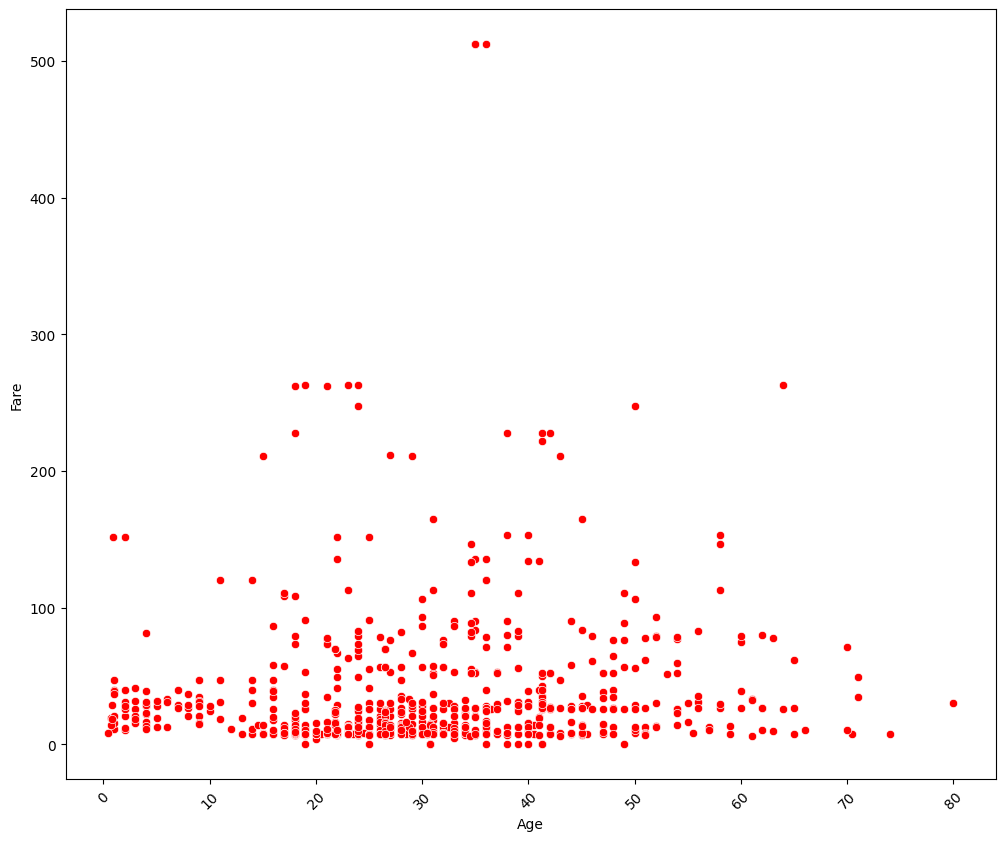

In [24]:
plt.figure(figsize=(12,10))
sns.scatterplot(data=df, x='Age', y='Fare', color='red')
plt.xticks(rotation=45)
plt.show()

In [25]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [26]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [27]:
df['Familysize'] = df['SibSp'] + df['Parch']
df['Familysize']

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    3
889    0
890    0
Name: Familysize, Length: 891, dtype: int64

In [28]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Familysize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.2500,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.0500,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.00,0,0,211536,13.0000,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.00,0,0,112053,30.0000,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.75,1,2,W./C. 6607,23.4500,S,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.00,0,0,111369,30.0000,C,0


In [29]:
df['Familysize'].max()

10

In [30]:
df[df['Familysize'] == 10 ]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Familysize
159,160,0,3,"Sage, Master. Thomas Henry",male,26.507589,8,2,CA. 2343,69.55,S,10
180,181,0,3,"Sage, Miss. Constance Gladys",female,21.750000,8,2,CA. 2343,69.55,S,10
201,202,0,3,"Sage, Mr. Frederick",male,26.507589,8,2,CA. 2343,69.55,S,10
324,325,0,3,"Sage, Mr. George John Jr",male,26.507589,8,2,CA. 2343,69.55,S,10
792,793,0,3,"Sage, Miss. Stella Anna",female,21.750000,8,2,CA. 2343,69.55,S,10
846,847,0,3,"Sage, Mr. Douglas Bullen",male,26.507589,8,2,CA. 2343,69.55,S,10
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,21.750000,8,2,CA. 2343,69.55,S,10


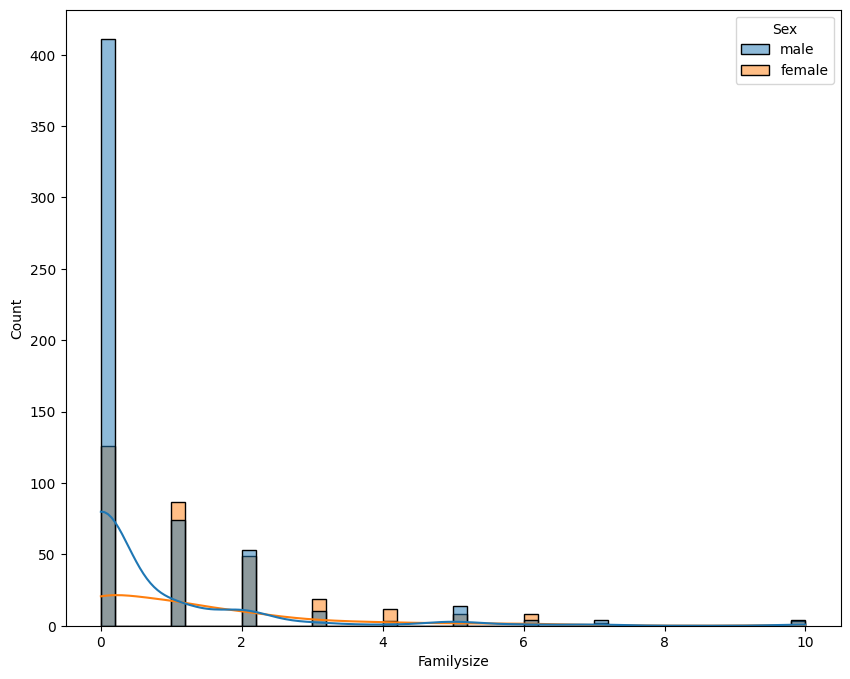

In [31]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Familysize' , hue='Sex' , kde=True , edgecolor='black' , bins=50)
plt.show()

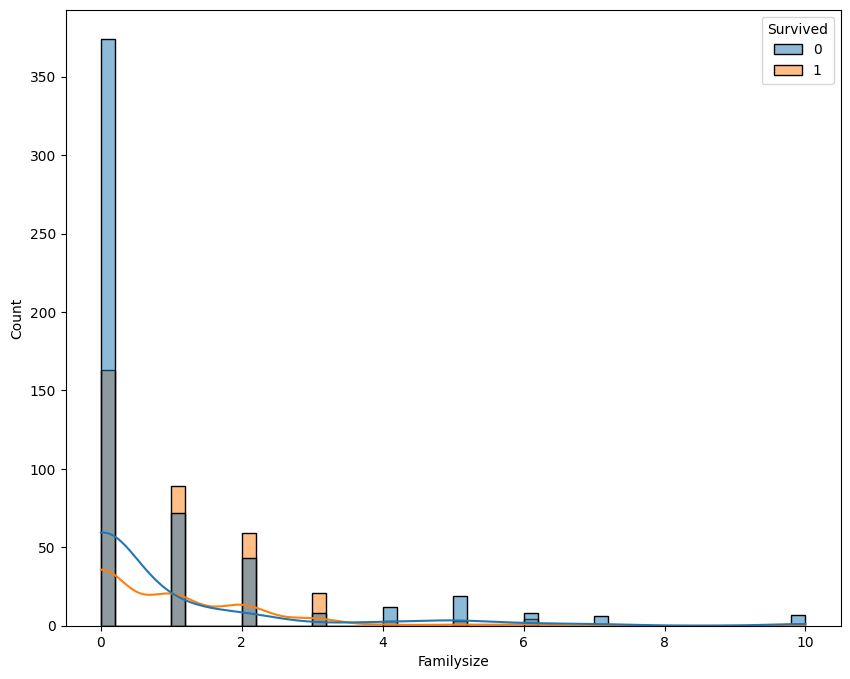

In [32]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Familysize' , hue='Survived' , kde=True , edgecolor='black' , bins=50)
plt.show()

In [33]:
df["Sex"] = df["Sex"].map({"male" : 1 , "female":0})

In [34]:
def isalone(x):
    if x == 0 :
        return 0 
    else :
        return 1

In [35]:
df['IsAlone'] = df['Familysize'].map(isalone)
df['IsAlone']

0      1
1      1
2      0
3      1
4      0
      ..
886    0
887    0
888    1
889    0
890    0
Name: IsAlone, Length: 891, dtype: int64

In [36]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Familysize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",1,22.00,1,0,A/5 21171,7.2500,S,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.00,1,0,PC 17599,71.2833,C,1,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.00,0,0,STON/O2. 3101282,7.9250,S,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.00,1,0,113803,53.1000,S,1,1
4,5,0,3,"Allen, Mr. William Henry",1,35.00,0,0,373450,8.0500,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.00,0,0,211536,13.0000,S,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.00,0,0,112053,30.0000,S,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,21.75,1,2,W./C. 6607,23.4500,S,3,1
889,890,1,1,"Behr, Mr. Karl Howell",1,26.00,0,0,111369,30.0000,C,0,0


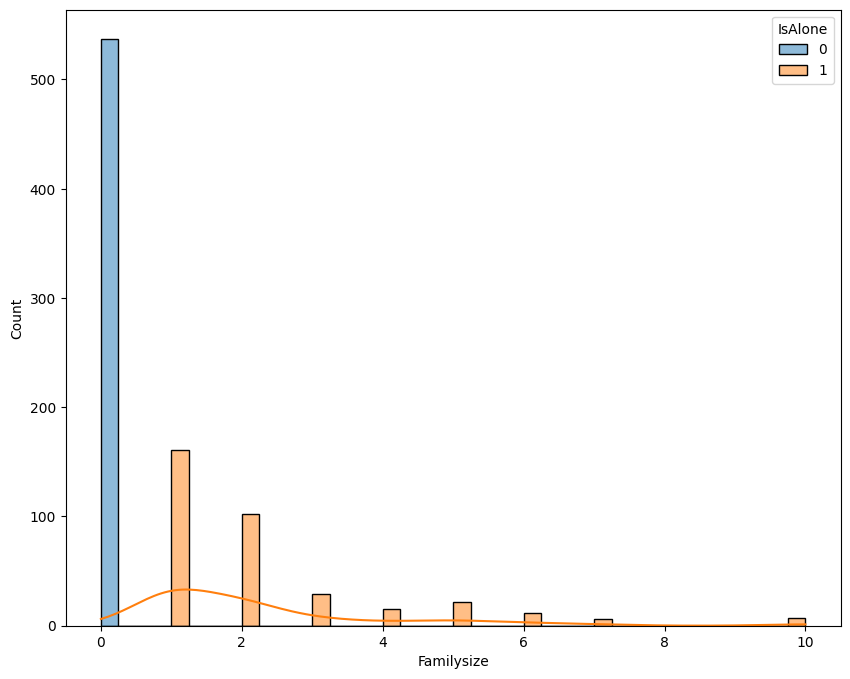

In [37]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Familysize' , hue='IsAlone' , edgecolor='black' , kde=True , bins=40)
plt.show()

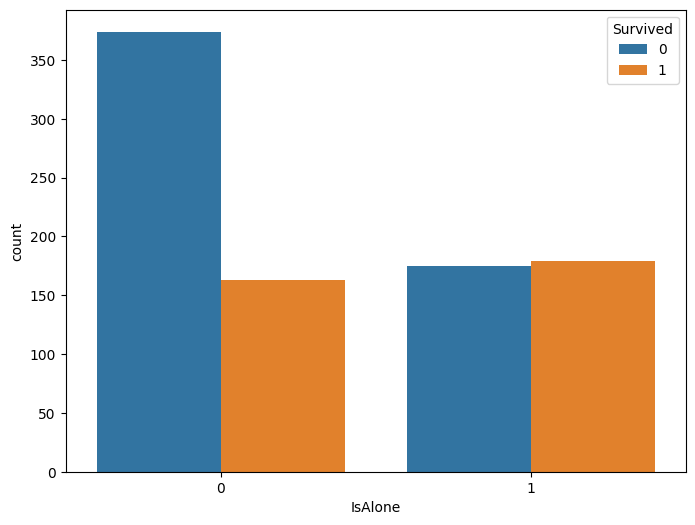

In [38]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='IsAlone', hue='Survived')
plt.show()

In [39]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Familysize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",1,22.00,1,0,A/5 21171,7.2500,S,1,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.00,1,0,PC 17599,71.2833,C,1,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.00,0,0,STON/O2. 3101282,7.9250,S,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.00,1,0,113803,53.1000,S,1,1
4,5,0,3,"Allen, Mr. William Henry",1,35.00,0,0,373450,8.0500,S,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.00,0,0,211536,13.0000,S,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.00,0,0,112053,30.0000,S,0,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,21.75,1,2,W./C. 6607,23.4500,S,3,1
889,890,1,1,"Behr, Mr. Karl Howell",1,26.00,0,0,111369,30.0000,C,0,0


In [40]:
pivot = df.pivot_table(index='Sex', columns='Pclass', values='Survived')
pivot

Pclass,1,2,3
Sex,,,
0,0.968085,0.921053,0.500000
1,0.368852,0.157407,0.135447


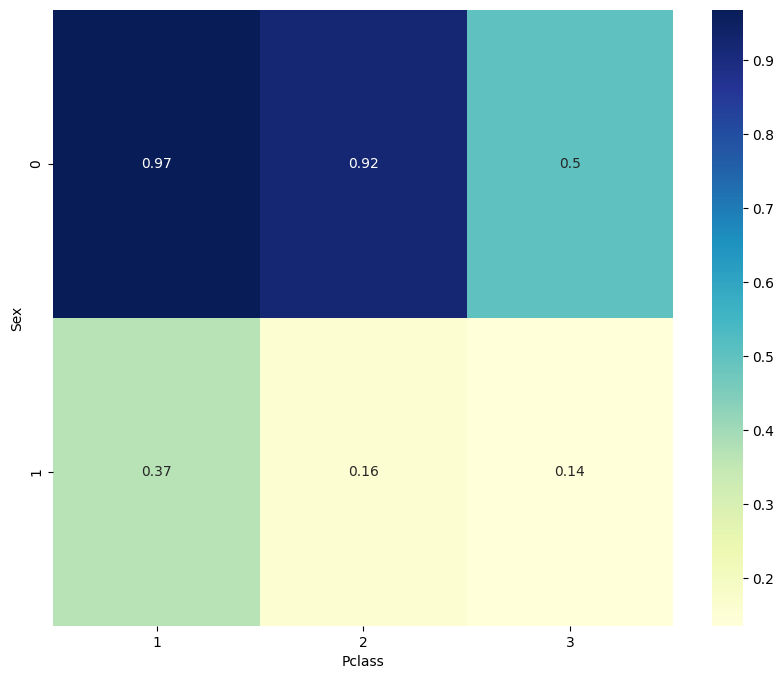

In [41]:
plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, cmap='YlGnBu')
plt.show()

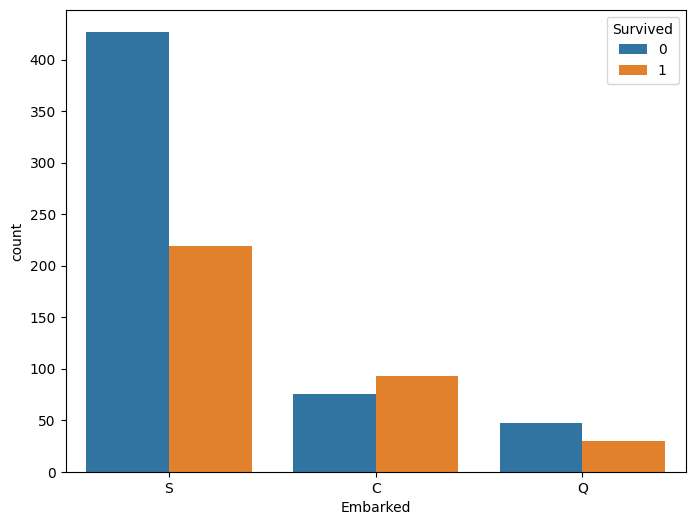

In [42]:
plt.figure(figsize=(8,6))
sns.countplot(data=df, x='Embarked', hue='Survived')
plt.show()